In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
df = pd.read_csv(r"../pre-calculated_data/phylum_result.tsv",sep='\t',index_col='taxonomy')
df = df.fillna(0)
df

,cpsnj01,cpsnj02,cpsnj03,cpsnj04,cpsnj08,cpsnj09,cpsnj10,cpsnj11,cpsnj13,cpsnj14,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
taxonomy,,,,,,,,,,,,,,,,,,,,,
Root; d__Archaea; p__Aenigmatarchaeota,0.02,0.02,0.02,0.01,0.02,0.02,0.01,0.01,0.02,0.01,...,0.01,0.02,0.02,0.01,0.01,0.01,0.02,0.03,0.02,0.01
Root; d__Archaea; p__Altiarchaeota,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Root; d__Archaea; p__Asgardarchaeota,0.02,0.01,0.02,0.02,0.02,0.03,0.03,0.02,0.02,0.02,...,0.02,0.02,0.01,0.02,0.02,0.03,0.02,0.01,0.02,0.02
Root; d__Archaea; p__B1Sed10-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,...,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00
Root; d__Archaea; p__Hadarchaeota,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Root; d__Bacteria; p__UBP17,0.01,0.02,0.01,0.01,0.00,0.00,0.00,0.00,0.01,0.01,...,0.00,0.01,0.01,0.01,0.00,0.01,0.01,0.00,0.02,0.01
Root; d__Bacteria; p__Verrucomicrobiota,2.63,2.47,3.63,3.45,3.32,8.16,6.75,4.12,8.44,4.35,...,3.76,10.17,4.09,4.66,5.27,4.95,4.81,3.68,3.68,3.13
Root; d__Bacteria; p__WOR-3,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,...,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00


In [3]:
def get_top_phyla_per_sample(df, top_n=8):
    top_phyla_dict = {}
    
    for sample in df.columns:
        top_phyla = df[sample].nlargest(top_n).index.tolist()
        top_phyla_dict[sample] = set(top_phyla)
    
    return top_phyla_dict
top_phyla = get_top_phyla_per_sample(df, top_n=8)
top_phyla

{'cpsnj01': {'Root; d__Bacteria; p__Acidobacteriota',
  'Root; d__Bacteria; p__Actinomycetota',
  'Root; d__Bacteria; p__Bacteroidota',
  'Root; d__Bacteria; p__Chloroflexota',
  'Root; d__Bacteria; p__Myxococcota',
  'Root; d__Bacteria; p__Planctomycetota',
  'Root; d__Bacteria; p__Pseudomonadota',
  'Root; d__Bacteria; p__Verrucomicrobiota'},
 'cpsnj02': {'Root; d__Bacteria; p__Acidobacteriota',
  'Root; d__Bacteria; p__Actinomycetota',
  'Root; d__Bacteria; p__Bacteroidota',
  'Root; d__Bacteria; p__Chloroflexota',
  'Root; d__Bacteria; p__Gemmatimonadota',
  'Root; d__Bacteria; p__Myxococcota',
  'Root; d__Bacteria; p__Planctomycetota',
  'Root; d__Bacteria; p__Pseudomonadota'},
 'cpsnj03': {'Root; d__Bacteria; p__Acidobacteriota',
  'Root; d__Bacteria; p__Actinomycetota',
  'Root; d__Bacteria; p__Chloroflexota',
  'Root; d__Bacteria; p__Gemmatimonadota',
  'Root; d__Bacteria; p__Myxococcota',
  'Root; d__Bacteria; p__Planctomycetota',
  'Root; d__Bacteria; p__Pseudomonadota',
  'R

In [4]:
def find_most_common_phyla(top_phyla, final_n=8):
    from collections import Counter
    phyla_counter = Counter()
    
    for phyla_set in top_phyla.values():
        phyla_counter.update(phyla_set)
    
    most_common = [phyla for phyla, count in phyla_counter.most_common(final_n)]
    
    return most_common, phyla_counter
most_common_phyla, phyla_counter = find_most_common_phyla(top_phyla, final_n=8)
phyla_counter

Counter({'Root; d__Bacteria; p__Bacteroidota': 26,
         'Root; d__Bacteria; p__Planctomycetota': 58,
         'Root; d__Bacteria; p__Pseudomonadota': 58,
         'Root; d__Bacteria; p__Verrucomicrobiota': 37,
         'Root; d__Bacteria; p__Chloroflexota': 46,
         'Root; d__Bacteria; p__Acidobacteriota': 58,
         'Root; d__Bacteria; p__Actinomycetota': 56,
         'Root; d__Bacteria; p__Myxococcota': 44,
         'Root; d__Bacteria; p__Gemmatimonadota': 39,
         'Root; d__Bacteria; p__Methylomirabilota': 26,
         'Root; d__Bacteria; p__Desulfobacterota_B': 14,
         'Root; d__Bacteria; p__Patescibacteria': 1,
         'Root; d__Archaea; p__Thermoproteota': 1})

In [5]:
most_common_phyla

['Root; d__Bacteria; p__Planctomycetota',
 'Root; d__Bacteria; p__Pseudomonadota',
 'Root; d__Bacteria; p__Acidobacteriota',
 'Root; d__Bacteria; p__Actinomycetota',
 'Root; d__Bacteria; p__Chloroflexota',
 'Root; d__Bacteria; p__Myxococcota',
 'Root; d__Bacteria; p__Gemmatimonadota',
 'Root; d__Bacteria; p__Verrucomicrobiota']

In [6]:
existing_phyla = [p for p in most_common_phyla if p in df.index]
selected_data = df.loc[existing_phyla] if existing_phyla else pd.DataFrame()
selected_data

,cpsnj01,cpsnj02,cpsnj03,cpsnj04,cpsnj08,cpsnj09,cpsnj10,cpsnj11,cpsnj13,cpsnj14,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
taxonomy,,,,,,,,,,,,,,,,,,,,,
Root; d__Bacteria; p__Planctomycetota,5.86,4.38,7.35,5.83,6.60,6.74,7.72,6.83,7.01,9.56,...,6.24,4.49,5.14,6.00,7.40,7.20,6.97,5.03,6.17,4.60
Root; d__Bacteria; p__Pseudomonadota,32.77,29.72,22.64,28.14,23.32,20.43,28.16,25.14,23.43,29.79,...,29.28,24.06,29.20,23.83,33.89,30.35,25.00,34.30,21.87,30.98
Root; d__Bacteria; p__Acidobacteriota,17.94,22.90,27.01,23.70,23.90,27.74,22.54,28.87,24.00,24.20,...,24.86,24.04,24.23,28.38,19.50,23.16,23.13,19.37,27.00,22.77
Root; d__Bacteria; p__Actinomycetota,19.94,8.77,8.04,6.74,12.03,6.05,7.28,8.37,5.06,3.99,...,7.59,11.38,12.02,11.78,6.58,7.17,6.10,10.25,13.58,11.87
Root; d__Bacteria; p__Chloroflexota,4.51,5.89,4.42,4.57,5.03,2.19,2.27,2.73,3.22,2.34,...,3.33,3.27,3.20,2.85,2.33,3.18,5.81,3.42,5.96,3.66
Root; d__Bacteria; p__Myxococcota,3.44,4.19,5.79,4.51,4.52,4.04,3.89,4.03,4.57,4.28,...,4.27,3.99,3.15,4.03,5.87,4.97,4.98,5.30,3.06,3.68
Root; d__Bacteria; p__Gemmatimonadota,2.51,5.35,4.38,4.85,3.04,2.12,2.00,2.06,2.74,2.18,...,3.78,2.61,3.31,3.02,3.00,2.96,3.78,3.85,3.61,4.53
Root; d__Bacteria; p__Verrucomicrobiota,2.63,2.47,3.63,3.45,3.32,8.16,6.75,4.12,8.44,4.35,...,3.76,10.17,4.09,4.66,5.27,4.95,4.81,3.68,3.68,3.13


In [7]:
other_phyla = [p for p in df.index if p not in existing_phyla]
if other_phyla:
    other_data = df.loc[other_phyla].sum(axis=0)
    other_data.name = 'Other'
else:
    other_data = pd.Series(0, index=df.columns, name='Other')
result_df = pd.concat([selected_data, pd.DataFrame([other_data])], axis=0)
result_df.index = [idx.replace('Root; d__Bacteria; p__', '') if idx != 'Other' else idx for idx in result_df.index]
result_df.columns = [col.lower().replace('_350', '') for col in result_df.columns]
result_df.columns = [f's{col}' if col.isdigit() else col for col in result_df.columns]
result_df

,cpsnj01,cpsnj02,cpsnj03,cpsnj04,cpsnj08,cpsnj09,cpsnj10,cpsnj11,cpsnj13,cpsnj14,...,snj08,snj09,snj10,snj11,snj13,snj14,snj15,snj16,snj19,snj20
Planctomycetota,5.86,4.38,7.35,5.83,6.60,6.74,7.72,6.83,7.01,9.56,...,6.24,4.49,5.14,6.00,7.40,7.20,6.97,5.03,6.17,4.60
Pseudomonadota,32.77,29.72,22.64,28.14,23.32,20.43,28.16,25.14,23.43,29.79,...,29.28,24.06,29.20,23.83,33.89,30.35,25.00,34.30,21.87,30.98
Acidobacteriota,17.94,22.90,27.01,23.70,23.90,27.74,22.54,28.87,24.00,24.20,...,24.86,24.04,24.23,28.38,19.50,23.16,23.13,19.37,27.00,22.77
Actinomycetota,19.94,8.77,8.04,6.74,12.03,6.05,7.28,8.37,5.06,3.99,...,7.59,11.38,12.02,11.78,6.58,7.17,6.10,10.25,13.58,11.87
Chloroflexota,4.51,5.89,4.42,4.57,5.03,2.19,2.27,2.73,3.22,2.34,...,3.33,3.27,3.20,2.85,2.33,3.18,5.81,3.42,5.96,3.66
Myxococcota,3.44,4.19,5.79,4.51,4.52,4.04,3.89,4.03,4.57,4.28,...,4.27,3.99,3.15,4.03,5.87,4.97,4.98,5.30,3.06,3.68
Gemmatimonadota,2.51,5.35,4.38,4.85,3.04,2.12,2.00,2.06,2.74,2.18,...,3.78,2.61,3.31,3.02,3.00,2.96,3.78,3.85,3.61,4.53
Verrucomicrobiota,2.63,2.47,3.63,3.45,3.32,8.16,6.75,4.12,8.44,4.35,...,3.76,10.17,4.09,4.66,5.27,4.95,4.81,3.68,3.68,3.13
Other,10.40,16.35,16.72,18.20,18.27,22.54,19.39,17.87,21.52,19.33,...,16.88,16.00,15.67,15.40,16.14,16.07,19.40,14.80,15.07,14.78


In [8]:
result = result_df.T
result

,Planctomycetota,Pseudomonadota,Acidobacteriota,Actinomycetota,Chloroflexota,Myxococcota,Gemmatimonadota,Verrucomicrobiota,Other
cpsnj01,5.86,32.77,17.94,19.94,4.51,3.44,2.51,2.63,10.40
cpsnj02,4.38,29.72,22.90,8.77,5.89,4.19,5.35,2.47,16.35
cpsnj03,7.35,22.64,27.01,8.04,4.42,5.79,4.38,3.63,16.72
cpsnj04,5.83,28.14,23.70,6.74,4.57,4.51,4.85,3.45,18.20
cpsnj08,6.60,23.32,23.90,12.03,5.03,4.52,3.04,3.32,18.27
cpsnj09,6.74,20.43,27.74,6.05,2.19,4.04,2.12,8.16,22.54
cpsnj10,7.72,28.16,22.54,7.28,2.27,3.89,2.00,6.75,19.39
cpsnj11,6.83,25.14,28.87,8.37,2.73,4.03,2.06,4.12,17.87
cpsnj13,7.01,23.43,24.00,5.06,3.22,4.57,2.74,8.44,21.52
cpsnj14,9.56,29.79,24.20,3.99,2.34,4.28,2.18,4.35,19.33


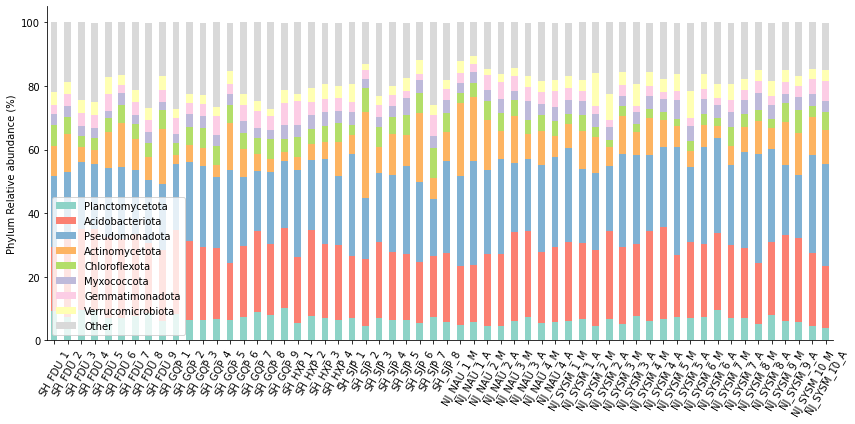

In [9]:
df = pd.read_csv(r"../pre-calculated_data/site_phylum.csv",index_col='taxonomy')
ax =df.plot.bar(stacked=True,color=['#8dd3c7','#fb8072','#80b1d3','#fdb462','#b3de69','#bebada','#fccde5','#ffffb3','#d9d9d9'],figsize=(12, 6))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False) 
ax.set_ylabel('Phylum Relative abundance (%)')
ax.set_xlabel('')
plt.xticks(rotation=60)
plt.tight_layout()

In [2]:
from skbio.stats.ordination import pcoa
from skbio.diversity import beta_diversity
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

In [5]:
otu_tab = pd.read_csv('../pre-calculated_data/all_otu_table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab

,AAAAAAAACGCGAACCGCTACGCCCGCAAGGTCGGATTTACGTCGGTGGCGTTGATCGAC,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCATCAGCGAATCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCGTGAAAGAAGCCCGCAAGCTGGGCATCGCCACGGTGGCGCTCATCGAC,AAAAAGATAGCCAACAAAGAAGCGCACCGGCTCAAAAAAAACGTCGCGGCAATCGTCCAA,AAAAATATTGCATTGAAAGAAGCGCAGAGATTAAACGTAAACACTTTTGGAATTGTTGAT,AAAAATGGGGCGCTCGCGGAAGCGAAGCGACTCGGCATTCCGATCGTTGGCATCGTCGAT,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AAACACAACGCCGTTGCTGAGGCGCGTCGGCTCAAAATCCCGGTCGTCGCGATAGTGGAT,AAACACAACGCGGTGAAGGAAGCCCGCCGCCTGTCGATCCCGGTCATCGCCATGCTCGAC,...,TGCGCAGTTCGTATCGACGACTGCAACGACAGGAATACCGAGCTTCTTGGCTTCGTGAAT,TGGAGAATCTGTGTCACAGAGAGCAATAACGGGAATGTTGACGTAGCTGGCCTCCTTGAT,TGGCACCTGGCGGTCGAGGAGGCCCGCAAGCTGCGGATCCCGATCATCGGCATCCTCGAC,TGTGAAAATGTTTCAGATGAATTTGCTTCAGCTAACATTCCAACTATAGGAATTGTTGAC,TTCAGAGAAGTTGTATCTGAAGCTTATGATATGGAGATTCCAGTTGTTGCGGCAATGGAT,TTGAAGATCTCGATAATGGTTGGCCGGGCACTCCGCATAAAAACAGTCTCGATGATCGAC,TTGAATATCGCATTCACAGAAGCAATACGGCTGGGTATGGGTACTTTCGGGATGGTGGAG,TTGCGCATCGCGGTCAGCGAGGCGAACAAGCTGGGCATCCCGATCGTCGCTATGGTGGAC,TTTGCTGCAGCGATAAAAGAGGCTTCATCCTTGAGTATTCCATCGTTAGGATTGATGGAT,TTTTATTCGTGTTTTTTTGAATCGACTTATTGTGGAATTCCGGCTATTGGTATGATTGAT
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#remove samples (<100 total count OTUs)
otus_filt = otu_tab[otu_tab.sum(axis=1) >= 100]
otus_filt_wo0 = otus_filt[otus_filt.sum(axis=1) > 0]
otus_filt_wo0 = otus_filt_wo0.loc[:,otus_filt_wo0.sum(axis=0) > 0]

otus_filt_wo0['Sum'] = otus_filt_wo0.sum(axis=1)
otus_RA = otus_filt_wo0.iloc[:, :].div(otus_filt_wo0.Sum, axis=0)
otus_RA = otus_RA.drop(['Sum'], axis=1)

#remove low RA
otus_RA = otus_RA.T
otus_RA['Mean'] = otus_RA.mean(axis=1)
otus_RA_filt = otus_RA.loc[otus_RA['Mean'].between(0.00001, 1)]
otus_RA_filt = otus_RA_filt.drop(['Mean'], axis=1)
otus_RA_filt 

,CPSNJ01_350,CPSNJ02_350,CPSNJ03_350,CPSNJ04_350,CPSNJ08_350,CPSNJ09_350,CPSNJ10_350,CPSNJ11_350,CPSNJ13_350,CPSNJ14_350,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000809,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000258,0.0,0.0,0.000782,0.0,0.0,0.0,0.0,0.0,0.00019


In [7]:
otus_RA_filt_zoom = otus_RA_filt * 1000000
np.set_printoptions(precision=5)
otus_np = otus_RA_filt_zoom.to_numpy()

minval = np.min(otus_np[np.nonzero(otus_np)])
pseudo = minval/2
otus_RA_filt_zoom.replace([0],pseudo, inplace=True)

otus_RA_filt_zoom = otus_RA_filt_zoom.T
otus_RA_filt_zoom

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
CPSNJ01_350,85.587128,85.587128,85.587128,85.587128,85.587128,886.328385,85.587128,85.587128,221.582096,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ02_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,501.253133,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ03_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ04_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ08_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ09_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ10_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ11_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ13_350,85.587128,808.843354,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ14_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128


In [9]:
np.set_printoptions(precision=5)
otus_rows = otus_RA_filt_zoom.index.tolist()
otus_cols = otus_RA_filt_zoom.columns.tolist()
otus_np = otus_RA_filt_zoom.to_numpy()

log_otus_tab = np.log10(otus_np)

In [10]:
otus_tab_F = pd.read_csv(r'../pre-calculated_data/abundance.csv',index_col='sample')
otus_tab_F

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
sample,,,,,,,,,,,,,,,,,,,,,
NJ_NAU_1_A,1.932408,1.932408,1.932408,1.932408,1.932408,2.947595,1.932408,1.932408,2.345535,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
NJ_NAU_2_A,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,2.700057,1.932408,1.932408,1.932408,1.932408,1.932408
NJ_NAU_3_A,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
NJ_NAU_4_A,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
NJ_SYSM_1_A,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
NJ_SYSM_2_A,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
NJ_SYSM_3_A,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
NJ_SYSM_4_A,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
NJ_SYSM_5_A,1.932408,2.907864,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408


In [11]:
otus_rows = otus_tab_F.index.tolist()

In [12]:
bc_div = beta_diversity('braycurtis', otus_tab_F, ids=otus_rows, validate=True)

In [13]:
distance_matrix = bc_div.data
similarity_matrix = 1 - distance_matrix
similarity_matrix

array([[1.     , 0.98014, 0.97868, ..., 0.97855, 0.97955, 0.98035],
       [0.98014, 1.     , 0.97945, ..., 0.9784 , 0.97942, 0.98002],
       [0.97868, 0.97945, 1.     , ..., 0.97787, 0.9809 , 0.9795 ],
       ...,
       [0.97855, 0.9784 , 0.97787, ..., 1.     , 0.97904, 0.98036],
       [0.97955, 0.97942, 0.9809 , ..., 0.97904, 1.     , 0.98107],
       [0.98035, 0.98002, 0.9795 , ..., 0.98036, 0.98107, 1.     ]])

In [14]:
similarity_df = pd.DataFrame(similarity_matrix, 
                             index=otus_rows,   # 设置行索引（样本名称）
                             columns=otus_rows)
similarity_df

,NJ_NAU_1_A,NJ_NAU_2_A,NJ_NAU_3_A,NJ_NAU_4_A,NJ_SYSM_1_A,NJ_SYSM_2_A,NJ_SYSM_3_A,NJ_SYSM_4_A,NJ_SYSM_5_A,NJ_SYSM_6_A,...,NJ_SYSM_1_M,NJ_SYSM_2_M,NJ_SYSM_3_M,NJ_SYSM_4_M,NJ_SYSM_5_M,NJ_SYSM_6_M,NJ_SYSM_7_M,NJ_SYSM_8_M,NJ_SYSM_9_M,NJ_SYSM_10_M
NJ_NAU_1_A,1.000000,0.980145,0.978678,0.978896,0.977313,0.976666,0.977597,0.977063,0.978366,0.976166,...,0.977477,0.979243,0.978304,0.978418,0.977698,0.977409,0.977913,0.978554,0.979547,0.980350
NJ_NAU_2_A,0.980145,1.000000,0.979448,0.981303,0.978149,0.977677,0.978387,0.977777,0.979642,0.977390,...,0.978162,0.979870,0.978826,0.978614,0.978517,0.978366,0.979161,0.978395,0.979423,0.980020
NJ_NAU_3_A,0.978678,0.979448,1.000000,0.979457,0.979829,0.976329,0.976916,0.977995,0.977678,0.976966,...,0.979546,0.978113,0.978104,0.978342,0.978495,0.977497,0.979074,0.977873,0.980902,0.979498
NJ_NAU_4_A,0.978896,0.981303,0.979457,1.000000,0.977878,0.977143,0.977689,0.977308,0.978849,0.976677,...,0.977996,0.979142,0.978434,0.977964,0.977776,0.977719,0.978976,0.977960,0.979201,0.979874
NJ_SYSM_1_A,0.977313,0.978149,0.979829,0.977878,1.000000,0.976738,0.977509,0.979027,0.978287,0.978171,...,0.980440,0.978135,0.978821,0.979287,0.978947,0.978519,0.979143,0.978824,0.979772,0.978772
NJ_SYSM_2_A,0.976666,0.977677,0.976329,0.977143,0.976738,1.000000,0.982174,0.979566,0.982175,0.978771,...,0.976803,0.982911,0.979300,0.979028,0.977451,0.979234,0.978248,0.976592,0.976714,0.977088
NJ_SYSM_3_A,0.977597,0.978387,0.976916,0.977689,0.977509,0.982174,1.000000,0.981179,0.982547,0.980183,...,0.977413,0.982979,0.980832,0.980802,0.978963,0.981013,0.979029,0.978193,0.977617,0.978312
NJ_SYSM_4_A,0.977063,0.977777,0.977995,0.977308,0.979027,0.979566,0.981179,1.000000,0.980523,0.979922,...,0.978806,0.980863,0.980792,0.983491,0.979488,0.980826,0.979556,0.978477,0.978001,0.978341
NJ_SYSM_5_A,0.978366,0.979642,0.977678,0.978849,0.978287,0.982175,0.982547,0.980523,1.000000,0.981481,...,0.978469,0.983457,0.980567,0.980277,0.979856,0.982452,0.979904,0.978797,0.978354,0.978433
NJ_SYSM_6_A,0.976166,0.977390,0.976966,0.976677,0.978171,0.978771,0.980183,0.979922,0.981481,1.000000,...,0.978814,0.979723,0.979689,0.979264,0.981526,0.982388,0.979795,0.978127,0.977297,0.977034


In [15]:
city_group = ['Nanjing'] * 14 + ['Shanghai'] * 30 + ['Nanjing'] * 14 # 假设前29个样本来自上海，后29个来自南京
#land_use_group = ['Campus']* 4 + ['Park'] *20 + ['Campus'] + ['Park'] * 10 + ['Campus'] + ['Park'] + ['Campus']* 7 +  ['Campus']* 4 + ['Park'] *10  # 假设土地利用类型交替出现
month_group = ['August']* 14 + ['July'] *10 + ['May'] + ['July'] * 10 + ['May'] + ['July'] + ['May']* 3 +  ['May']* 4 + ['May'] *14  # 假设土地利用类型交替出现

city_palette = {'Shanghai': '#d8b365', 'Nanjing': '#5ab4ac'}
month_palette = {'May': '#d95f02',  'July': '#1b9e77', 'August': '#7570b3'}

In [16]:
row_colors_city = [city_palette[city] for city in city_group]
#row_colors_land_use = [land_use_palette[lu] for lu in land_use_group]
row_colors_month = [month_palette[lu] for lu in month_group]

In [17]:
row_colors_combined = pd.DataFrame({'City': row_colors_city, 
                                    #'Land Use': row_colors_land_use,
                                    'Month': row_colors_month},
                                    index=otus_rows)

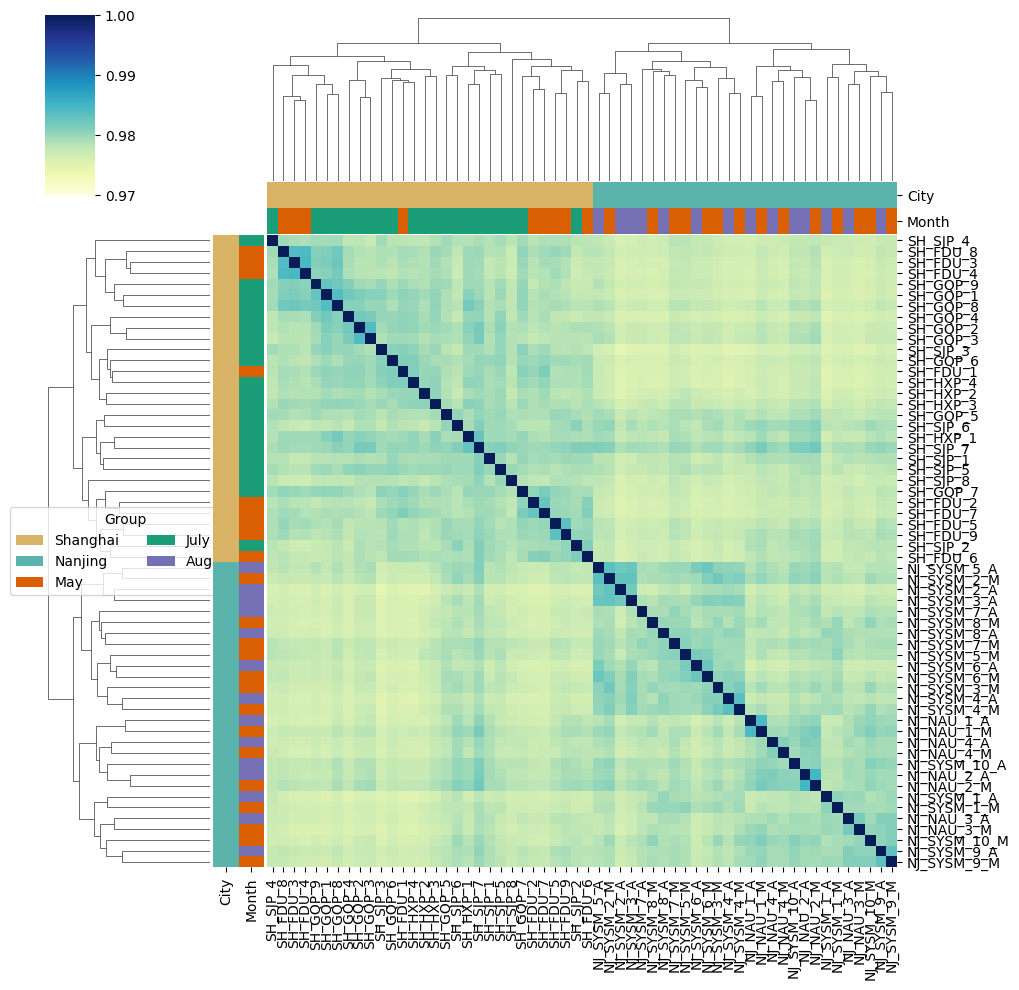

In [18]:
cmap = "YlGnBu"  

g = sns.clustermap(similarity_df,
                   cmap=cmap,           
                   vmin=0.97,              
                   vmax=1,              
                   method='complete', 
                   metric='euclidean',
                   yticklabels=1,  
                   xticklabels=1,  
                   annot=False, 
                   row_colors=row_colors_combined, 
                   col_colors=row_colors_combined, 
                   figsize=(10, 10))
for label, color in city_palette.items():
    g.ax_row_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
for label, color in month_palette.items():
    g.ax_row_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)    
g.ax_row_dendrogram.legend(title='Group', loc='center', ncol=2, bbox_to_anchor=(0.5, 0.5))